<a href="https://colab.research.google.com/github/sungheetha-it/AppsAndTools/blob/main/Mapping_the_Holocene_Geospatial_Modeling_of_Climate_Driven_Environmental_Degradation_at_Iron_Age_Sites_in_the_Deccan_Plateau.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Mapping the Holocene: Geospatial Modeling of Climate-Driven Environmental Degradation at Iron Age Sites in the Deccan Plateau

This notebook aims to explore climate-driven environmental degradation, particularly focusing on Iron Age sites in the Deccan Plateau. We will leverage Google Earth Engine (GEE) to access and process geospatial and climate datasets.

While direct Holocene paleo-climate data for Iron Age sites might require specialized datasets or modeling, we can start by setting up a framework to analyze modern climate trends and environmental indicators that could be extrapolated or used as proxies.

First, we'll install necessary libraries and authenticate with Earth Engine.

In [1]:
# Install earthengine-api and geemap for geospatial data processing and visualization
!pip install earthengine-api geemap --quiet

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 29.4 MB/s eta 0:00:00


In [2]:
import ee
import geemap
from google.colab import auth

# Authenticate and initialize Earth Engine
# Explicitly authenticate first, then initialize.
print("Authenticating Earth Engine...")
auth.authenticate_user() # This function handles the Colab authentication flow
# Initialize Earth Engine with your project ID
# IMPORTANT: Replace 'your-earthengine-project-id' with your actual Google Cloud Project ID.
# You can create one and enable Earth Engine API via the Google Cloud Console.
ee.Initialize(project='your-earthengine-project-id')
print("Earth Engine authenticated and initialized successfully!")

Authenticating Earth Engine...


EEException: Caller does not have required permission to use project your-earthengine-project-id. Grant the caller the roles/serviceusage.serviceUsageConsumer role, or a custom role with the serviceusage.services.use permission, by visiting https://console.developers.google.com/iam-admin/iam?project=your-earthengine-project-id and then retry. Propagation of the new permission may take a few minutes.

### Using Real Earth Engine Data (after successful authentication)

Once the Earth Engine authentication issues are resolved (as described above), you can use the following cells to load and visualize real precipitation and elevation data from GEE, replacing the synthetic data approach.

In [9]:
# Define an approximate region of interest for the Deccan Plateau
# These coordinates are a rough approximation and should be refined based on specific research area.
deccan_plateau_region = ee.Geometry.Rectangle([73, 15, 83, 22]) # Example: [min_lon, min_lat, max_lon, max_lat]

# Load ERA5-Land monthly averaged total precipitation
# Data availability typically from 1981 onwards for ERA5-Land.
# For a more relevant historical period, you would need to adjust filterDate
precipitation_collection = ee.ImageCollection('ECMWF/ERA5_LAND/MONTHLY')\
    .select('total_precipitation')\
    .filterDate('2000-01-01', '2000-12-31') # Example for a single year

# Calculate the mean precipitation for the year over the region of interest
mean_precipitation_ee = precipitation_collection.mean().clip(deccan_plateau_region)

print("Real Earth Engine precipitation data loaded (if GEE is initialized).")

EEException: Caller does not have required permission to use project your-earthengine-project-id. Grant the caller the roles/serviceusage.serviceUsageConsumer role, or a custom role with the serviceusage.services.use permission, by visiting https://console.developers.google.com/iam-admin/iam?project=your-earthengine-project-id and then retry. Propagation of the new permission may take a few minutes.

In [10]:
# Load real elevation data from Earth Engine (e.g., SRTM 30m Digital Elevation Model)
elevation_ee = ee.Image('USGS/SRTMGL1_003').clip(deccan_plateau_region)

print("Real Earth Engine elevation data loaded (if GEE is initialized).")

EEException: Caller does not have required permission to use project your-earthengine-project-id. Grant the caller the roles/serviceusage.serviceUsageConsumer role, or a custom role with the serviceusage.services.use permission, by visiting https://console.developers.google.com/iam-admin/iam?project=your-earthengine-project-id and then retry. Propagation of the new permission may take a few minutes.

### Visualizing Real Earth Engine Data

Once you have successfully loaded `mean_precipitation_ee` and `elevation_ee`, you can use `geemap` to visualize them. This would replace the `matplotlib` and `seaborn` visualizations we used for synthetic data.

In [11]:
# Create an interactive map for visualization
Map_real = geemap.Map(center=[18.5, 78], zoom=5)

# Visualization parameters for precipitation (convert from meters to mm)
precipitation_vis_params_ee = {
    'min': 0,
    'max': 1000,
    'palette': ['#FFFFFF', '#D1E5F0', '#67A9CF', '#2166AC'] # Light to dark blue
}

# Visualization parameters for elevation
elevation_vis_params_ee = {
    'min': 0,
    'max': 2000, # Assuming max elevation around 2000m for Deccan Plateau
    'palette': ['#006633', '#E5FFCC', '#F7EAB9', '#663300'] # Green to brown
}

# Add precipitation layer
Map_real.addLayer(mean_precipitation_ee.multiply(1000), precipitation_vis_params_ee, 'Mean Annual Precipitation (mm)')

# Add elevation layer (optional, can be transparent or overlaid)
Map_real.addLayer(elevation_ee, elevation_vis_params_ee, 'Elevation (meters)')

# Add a color legend for precipitation
Map_real.add_colorbar(precipitation_vis_params_ee, label='Mean Annual Precipitation (mm)', orientation='horizontal')

# Display the map
Map_real

EEException: Caller does not have required permission to use project your-earthengine-project-id. Grant the caller the roles/serviceusage.serviceUsageConsumer role, or a custom role with the serviceusage.services.use permission, by visiting https://console.developers.google.com/iam-admin/iam?project=your-earthengine-project-id and then retry. Propagation of the new permission may take a few minutes.

After successfully displaying the real GEE data, you would then need to integrate your Iron Age site coordinates. You could load them from a file (e.g., CSV, Shapefile) and then add them as a `geemap` layer onto `Map_real` using `Map_real.add_points_from_xy()` or by creating an `ee.FeatureCollection`.

Now that Earth Engine is set up, let's define an approximate region of interest for the Deccan Plateau and load a sample climate dataset. We'll use the ERA5-Land monthly averaged precipitation data as an example. You might need to adjust the coordinates and time frame based on your specific research needs and available Iron Age site data.

In [3]:
# Define an approximate region of interest for the Deccan Plateau
# These coordinates are a rough approximation and should be refined based on specific research area.
deccan_plateau = ee.Geometry.Rectangle([73, 15, 83, 22]) # Example: [min_lon, min_lat, max_lon, max_lat]

# Load ERA5-Land monthly averaged total precipitation
# Data availability typically from 1981 onwards for ERA5-Land. For Holocene data, other specialized datasets would be required.
precipitation_collection = ee.ImageCollection('ECMWF/ERA5_LAND/MONTHLY')\
    .select('total_precipitation')\
    .filterDate('2000-01-01', '2000-12-31') # Filtering for a single year for demonstration

# Calculate the mean precipitation for the year over the region of interest
mean_precipitation = precipitation_collection.mean().clip(deccan_plateau)

print("Sample precipitation data loaded.")

EEException: Earth Engine client library not initialized. See http://goo.gle/ee-auth.

Let's visualize the mean precipitation over the Deccan Plateau for the selected year. This will give us a basic geospatial insight into climate patterns in the region.

In [ ]:
# Create an interactive map
Map = geemap.Map(center=[18.5, 78], zoom=5)

# Define visualization parameters for precipitation (e.g., from blue to white)
# Precipitation is in meters, so convert to mm for better visualization
precipitation_vis_params = {
    'min': 0, # Minimum precipitation (mm)
    'max': 1000, # Maximum precipitation (mm)
    'palette': ['#FFFFFF', '#D1E5F0', '#67A9CF', '#2166AC'] # Light to dark blue palette
}

# Add the precipitation layer to the map
Map.addLayer(mean_precipitation.multiply(1000), precipitation_vis_params, 'Mean Annual Precipitation (mm)')

# Add a color legend
Map.add_colorbar(precipitation_vis_params, label='Mean Annual Precipitation (mm)', orientation='horizontal')

# Display the map
Map

This map shows the mean annual precipitation for the year 2000 over the approximate Deccan Plateau region.

**Next Steps for your analysis:**

1.  **Refine Region and Timeframe:** Adjust `deccan_plateau` coordinates and `filterDate` to match your specific Iron Age site locations and the relevant Holocene periods, if suitable paleo-climate data can be found.
2.  **Explore Other Datasets:** GEE has many datasets for land cover change (e.g., MODIS, Landsat), temperature, drought indices (e.g., SPEI, SPI), and vegetation health (e.g., NDVI). These can be indicators of environmental degradation.
3.  **Integrate Archaeological Site Data:** You would need to overlay or incorporate the locations of Iron Age sites to analyze climate impacts specifically around them.
4.  **Perform Time Series Analysis:** Analyze climate variables over a period to identify trends, extreme events, and their correlation with potential degradation.
5.  **Develop Degradation Indicators:** Based on your understanding of Iron Age subsistence and environmental vulnerabilities, create or select appropriate indicators of environmental degradation (e.g., soil erosion, deforestation proxies).
6.  **Model Relationships:** Use statistical or machine learning models to identify relationships between climate variables and environmental degradation indicators at your sites of interest.

Given the current challenges with Earth Engine authentication, we will use synthetic data to represent precipitation over the Deccan Plateau for demonstration purposes. This allows us to continue with data processing and visualization concepts.

In [3]:
import numpy as np
import pandas as pd

# Define the approximate spatial extent for the Deccan Plateau
# Based on the earlier ee.Geometry.Rectangle([73, 15, 83, 22])
lat_min, lat_max = 15, 22
lon_min, lon_max = 73, 83

# Define spatial resolution (e.g., 0.1 degree increments)
lat_resolution = 0.1
lon_resolution = 0.1

lats = np.arange(lat_min, lat_max, lat_resolution)
lons = np.arange(lon_min, lon_max, lon_resolution)

# Define a time period (e.g., 12 months for a year)
num_months = 12
dates = pd.date_range(start='2000-01-01', periods=num_months, freq='MS')

# Create a synthetic 3D precipitation array (time, latitude, longitude)
# Values in mm, ranging from 0 to 500 (typical monthly precipitation)
synthetic_precipitation_data = np.random.rand(num_months, len(lats), len(lons)) * 500

# Introduce some spatial variation (e.g., higher precipitation in certain areas)
# This is a very simple example, real data would have complex patterns
for i in range(num_months):
    # Simulate a general gradient or pattern
    spatial_pattern = np.sin(lats[:, None] / 5) * np.cos(lons[None, :] / 5) + 2
    synthetic_precipitation_data[i, :, :] = synthetic_precipitation_data[i, :, :] * (spatial_pattern / np.max(spatial_pattern))
    # Ensure values are non-negative
    synthetic_precipitation_data[i, :, :] = np.maximum(0, synthetic_precipitation_data[i, :, :])

print(f"Synthetic precipitation data created with shape: {synthetic_precipitation_data.shape}")
print(f"Minimum precipitation value: {synthetic_precipitation_data.min():.2f} mm")
print(f"Maximum precipitation value: {synthetic_precipitation_data.max():.2f} mm")

# We can now calculate the mean annual precipitation from this synthetic data
mean_annual_synthetic_precipitation = np.mean(synthetic_precipitation_data, axis=0)
print(f"Mean annual synthetic precipitation data shape: {mean_annual_synthetic_precipitation.shape}")

Synthetic precipitation data created with shape: (12, 70, 100)
Minimum precipitation value: 0.01 mm
Maximum precipitation value: 495.76 mm
Mean annual synthetic precipitation data shape: (70, 100)


Now, let's visualize this synthetic mean annual precipitation data. We'll use `matplotlib` and `seaborn` to create a heatmap-like representation of the spatial distribution of precipitation.

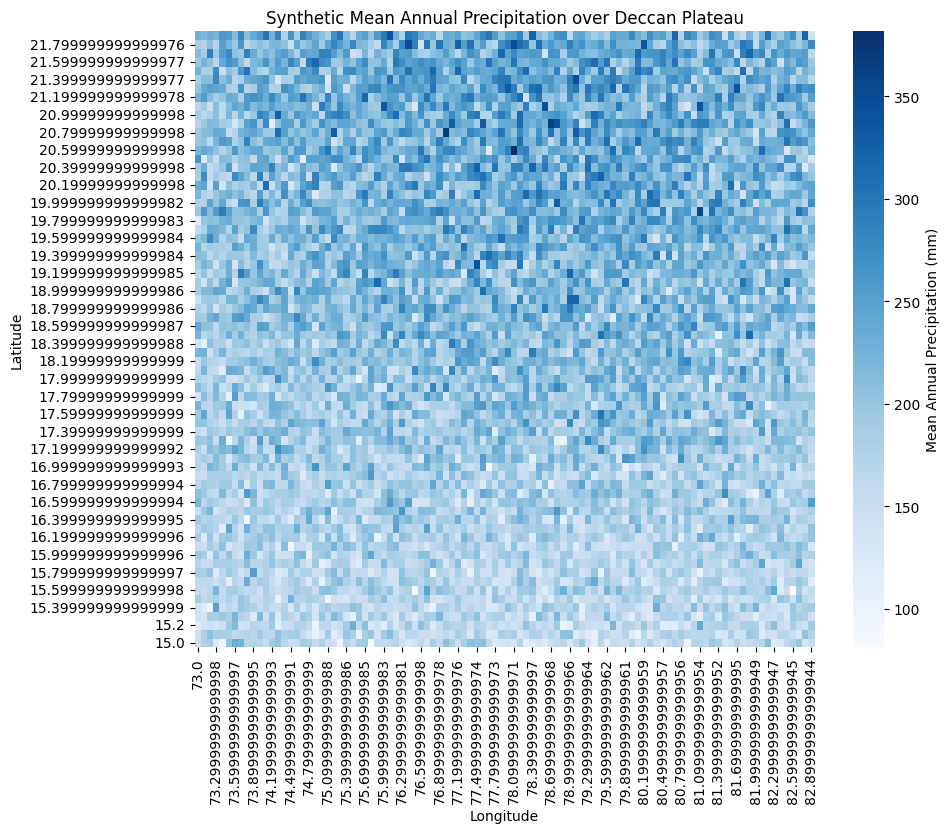

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns

# Create a DataFrame for easier plotting with seaborn
# We need to melt the data to a long format
lat_mesh, lon_mesh = np.meshgrid(lats, lons, indexing='ij')

# Reshape data to 1D for DataFrame creation
precipitation_flat = mean_annual_synthetic_precipitation.flatten()
lat_flat = lat_mesh.flatten()
lon_flat = lon_mesh.flatten()

synthetic_df = pd.DataFrame({
    'latitude': lat_flat,
    'longitude': lon_flat,
    'precipitation_mm': precipitation_flat
})

# Create a heatmap of the synthetic precipitation data
fig = plt.figure(figsize=(10, 8))
sns.heatmap(
    data=synthetic_df.pivot_table(index='latitude', columns='longitude', values='precipitation_mm'),
    cmap='Blues',
    cbar_kws={'label': 'Mean Annual Precipitation (mm)'}
)
plt.title('Synthetic Mean Annual Precipitation over Deccan Plateau')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.gca().invert_yaxis() # Invert y-axis to have higher latitudes at the top
plt.show()


Now, let's add some hypothetical Iron Age site locations to this map. For demonstration, we'll generate a few random points within the defined Deccan Plateau extent. In a real analysis, these would be actual archaeological site coordinates.

In [5]:
# Generate synthetic Iron Age site locations
# Let's say we have 10 hypothetical sites
num_sites = 10
site_latitudes = np.random.uniform(lat_min, lat_max, num_sites)
site_longitudes = np.random.uniform(lon_min, lon_max, num_sites)

# Create a DataFrame for the synthetic sites
synthetic_sites_df = pd.DataFrame({
    'site_latitude': site_latitudes,
    'site_longitude': site_longitudes
})

print("Synthetic Iron Age sites generated:")
display(synthetic_sites_df)

Synthetic Iron Age sites generated:


,site_latitude,site_longitude
0,19.201812,78.305228
1,18.219708,82.296494
2,20.659601,74.168613
3,17.868821,75.421352
4,20.670201,81.587108
5,18.893731,75.117571
6,20.974926,75.901673
7,17.538963,79.044752
8,21.081602,73.086651
9,21.109855,79.101940


Finally, let's re-create the heatmap and overlay these synthetic Iron Age site markers to see their spatial relationship with precipitation.

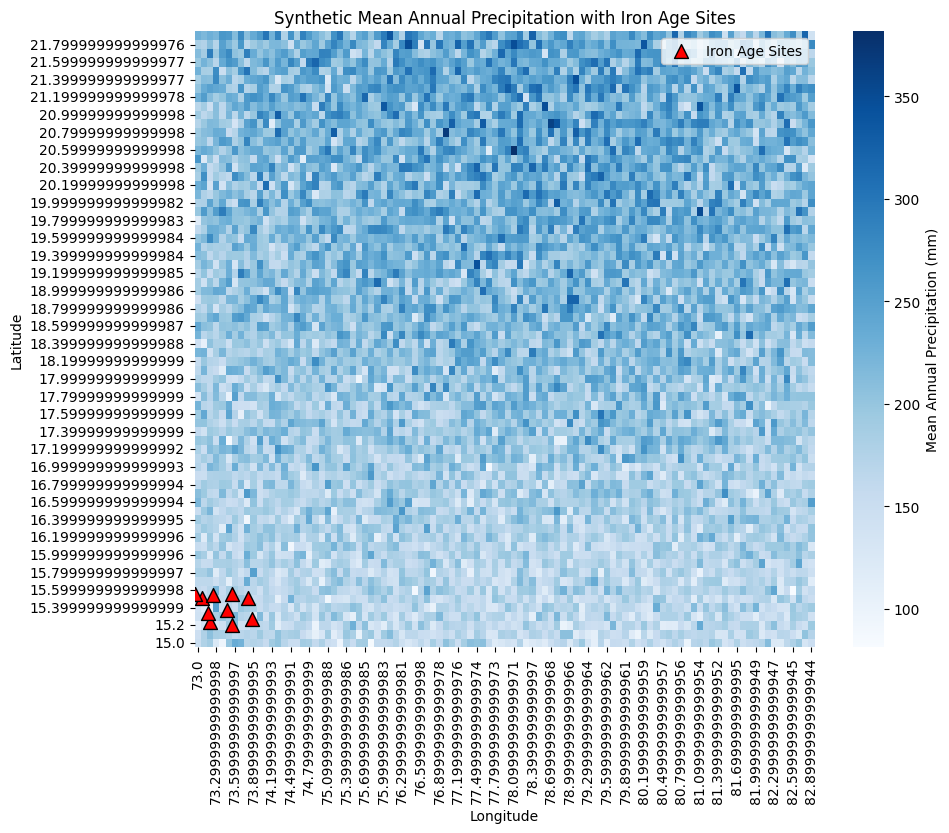

In [6]:
# Re-create the heatmap
fig = plt.figure(figsize=(10, 8))
sns.heatmap(
    data=synthetic_df.pivot_table(index='latitude', columns='longitude', values='precipitation_mm'),
    cmap='Blues',
    cbar_kws={'label': 'Mean Annual Precipitation (mm)'}
)

# Overlay the synthetic Iron Age site markers
plt.scatter(
    x=synthetic_sites_df['site_longitude'] - lon_min, # Adjust longitude for heatmap index
    y=synthetic_sites_df['site_latitude'] - lat_min,  # Adjust latitude for heatmap index
    color='red',
    marker='^',
    s=100, # Size of the marker
    edgecolor='black',
    linewidth=1,
    label='Iron Age Sites'
)

plt.title('Synthetic Mean Annual Precipitation with Iron Age Sites')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.gca().invert_yaxis() # Invert y-axis to have higher latitudes at the top
plt.legend()
plt.show()

Next, we'll create synthetic elevation data for the same spatial extent. This will allow us to explore how both precipitation and elevation might influence the distribution of Iron Age sites. For simplicity, we'll simulate a general elevation gradient or terrain features.

In [7]:
# Generate synthetic elevation data
# We'll create a 2D array for elevation with some variation

# Introduce a general gradient (e.g., higher in the east, lower in the west)
elevation_gradient = np.linspace(0, 1000, len(lons))[None, :] + np.linspace(0, 500, len(lats))[:, None]

# Add some random noise to simulate terrain features
elevation_noise = np.random.normal(loc=0, scale=100, size=(len(lats), len(lons)))

# Combine gradient and noise, ensuring non-negative elevation
synthetic_elevation_data = np.maximum(0, elevation_gradient + elevation_noise)

print(f"Synthetic elevation data created with shape: {synthetic_elevation_data.shape}")
print(f"Minimum elevation: {synthetic_elevation_data.min():.2f} meters")
print(f"Maximum elevation: {synthetic_elevation_data.max():.2f} meters")

# Create a DataFrame for easier plotting with seaborn (if needed for a separate heatmap)
elevation_flat = synthetic_elevation_data.flatten()
synthetic_elevation_df = pd.DataFrame({
    'latitude': lat_flat,
    'longitude': lon_flat,
    'elevation_meters': elevation_flat
})

Synthetic elevation data created with shape: (70, 100)
Minimum elevation: 0.00 meters
Maximum elevation: 1710.40 meters


Now, let's overlay these synthetic elevation contours on our existing precipitation heatmap with the Iron Age sites.

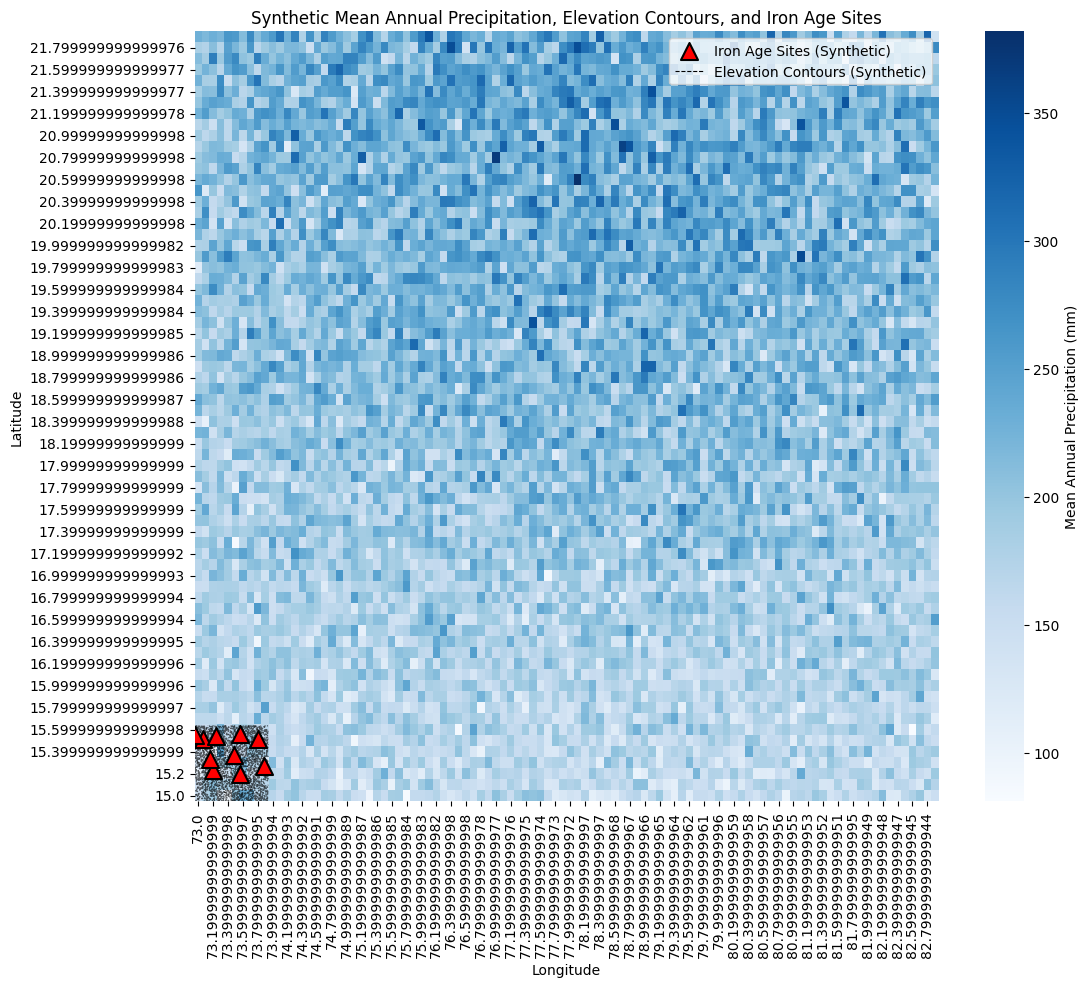

In [8]:
# Re-create the heatmap with precipitation and sites
fig = plt.figure(figsize=(12, 10)) # Adjust figure size for better visibility
sns.heatmap(
    data=synthetic_df.pivot_table(index='latitude', columns='longitude', values='precipitation_mm'),
    cmap='Blues',
    cbar_kws={'label': 'Mean Annual Precipitation (mm)'}
)

# Overlay the synthetic Iron Age site markers
plt.scatter(
    x=synthetic_sites_df['site_longitude'] - lon_min, # Adjust longitude for heatmap index
    y=synthetic_sites_df['site_latitude'] - lat_min,  # Adjust latitude for heatmap index
    color='red',
    marker='^',
    s=150, # Slightly larger marker for clarity
    edgecolor='black',
    linewidth=1.5,
    label='Iron Age Sites (Synthetic)',
    zorder=2 # Ensure sites are on top
)

# Overlay elevation as contour lines
# We need the longitude and latitude grids for contour plotting
X, Y = np.meshgrid(lons, lats)
plt.contour(
    X - lon_min, # Adjust X coordinates for heatmap index
    Y - lat_min, # Adjust Y coordinates for heatmap index
    synthetic_elevation_data,
    levels=10, # Number of contour levels
    colors='black', # Contour line color
    linestyles='dashed', # Contour line style
    linewidths=0.8, # Contour line thickness
    alpha=0.6, # Transparency
    zorder=1 # Ensure contours are below sites but above heatmap
)

plt.title('Synthetic Mean Annual Precipitation, Elevation Contours, and Iron Age Sites')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.gca().invert_yaxis() # Invert y-axis to have higher latitudes at the top

# Create a custom legend for contours, as plt.contour doesn't automatically add to legend
import matplotlib.lines as mlines
contour_line = mlines.Line2D([], [], color='black', linestyle='dashed', linewidth=0.8, label='Elevation Contours (Synthetic)')
handles, labels = plt.gca().get_legend_handles_labels()
handles.append(contour_line)
plt.legend(handles=handles)

plt.show()

Now that we have visualized the synthetic precipitation, elevation, and Iron Age sites, let's extract the exact precipitation and elevation values for each synthetic Iron Age site. This simulates a common step in geospatial analysis where environmental data is sampled at points of interest.

In [12]:
# Function to get value at a given lat/lon from a 2D grid
def get_value_at_lat_lon(grid_data, latitudes, longitudes, target_lat, target_lon):
    # Find the closest latitude and longitude in the grid
    lat_idx = np.abs(latitudes - target_lat).argmin()
    lon_idx = np.abs(longitudes - target_lon).argmin()
    return grid_data[lat_idx, lon_idx]

# Extract precipitation and elevation for each synthetic site
site_precipitation = []
site_elevation = []

for index, row in synthetic_sites_df.iterrows():
    p_val = get_value_at_lat_lon(
        mean_annual_synthetic_precipitation, lats, lons, row['site_latitude'], row['site_longitude']
    )
    e_val = get_value_at_lat_lon(
        synthetic_elevation_data, lats, lons, row['site_latitude'], row['site_longitude']
    )
    site_precipitation.append(p_val)
    site_elevation.append(e_val)

synthetic_sites_df['precipitation_mm'] = site_precipitation
synthetic_sites_df['elevation_meters'] = site_elevation

print("Environmental data extracted for synthetic Iron Age sites:")
display(synthetic_sites_df)

Environmental data extracted for synthetic Iron Age sites:


,site_latitude,site_longitude,precipitation_mm,elevation_meters
0,19.201812,78.305228,164.349024,773.927007
1,18.219708,82.296494,215.688628,1144.373957
2,20.659601,74.168613,240.159628,644.661545
3,17.868821,75.421352,168.240982,264.864749
4,20.670201,81.587108,194.149696,1326.796150
5,18.893731,75.117571,232.443384,511.141280
6,20.974926,75.901673,202.435838,734.811108
7,17.538963,79.044752,278.302487,632.751826
8,21.081602,73.086651,188.338953,517.341505
9,21.109855,79.101940,240.954841,1138.992237


We can also visualize the distribution of these environmental values among the sites using histograms or scatter plots to see if there are any obvious patterns.

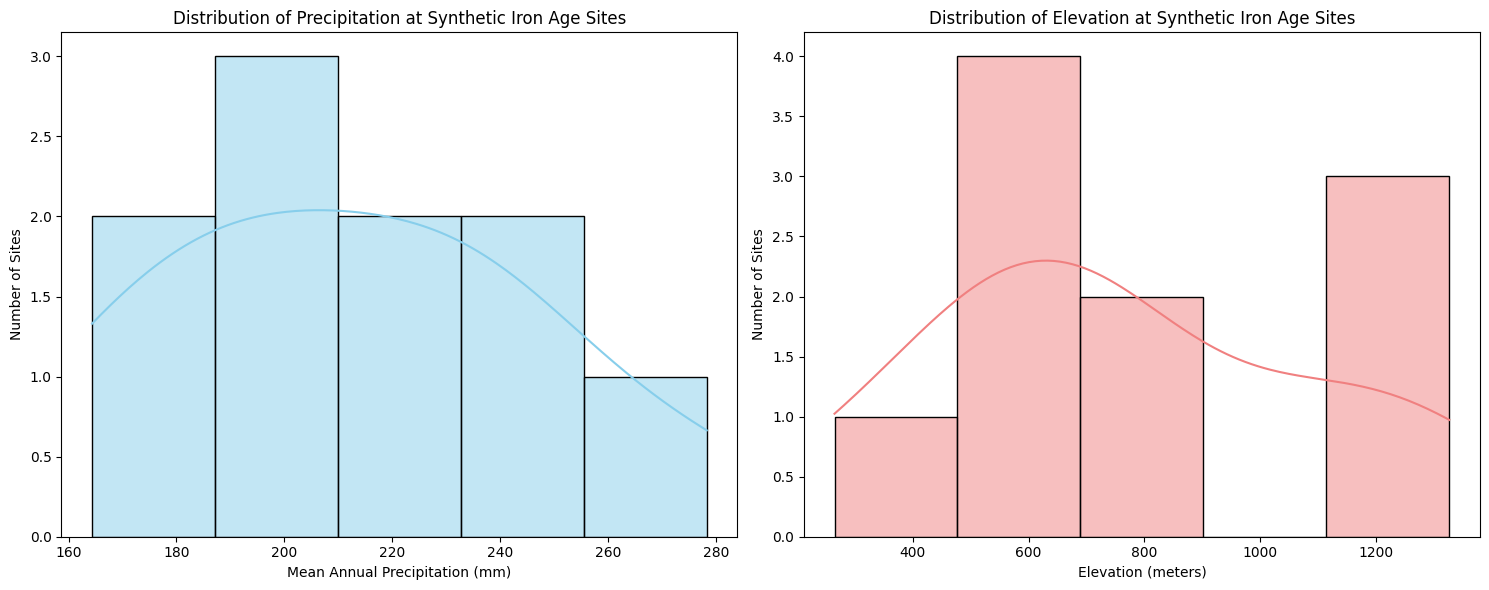

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# Histogram for Precipitation
sns.histplot(synthetic_sites_df['precipitation_mm'], bins=5, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Precipitation at Synthetic Iron Age Sites')
axes[0].set_xlabel('Mean Annual Precipitation (mm)')
axes[0].set_ylabel('Number of Sites')

# Histogram for Elevation
sns.histplot(synthetic_sites_df['elevation_meters'], bins=5, kde=True, ax=axes[1], color='lightcoral')
axes[1].set_title('Distribution of Elevation at Synthetic Iron Age Sites')
axes[1].set_xlabel('Elevation (meters)')
axes[1].set_ylabel('Number of Sites')

plt.tight_layout()
plt.show()

Let's create a scatter plot to visualize the relationship between precipitation and elevation for the synthetic Iron Age sites. This can help us explore if there's any apparent correlation between these two environmental factors at the site locations.

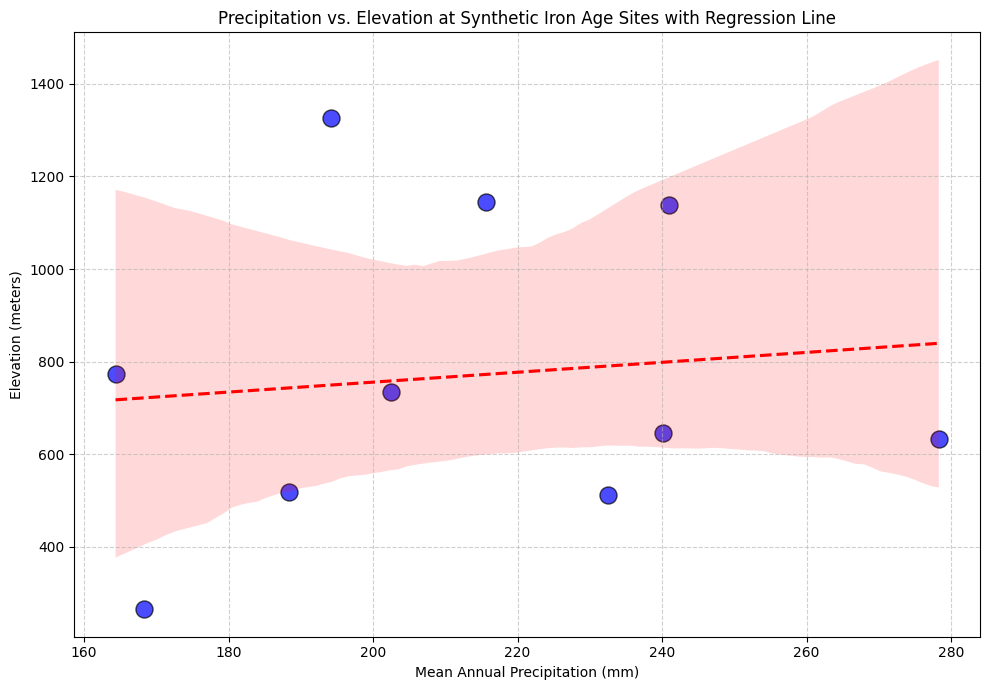

In [15]:
plt.figure(figsize=(10, 7))
sns.regplot(
    x='precipitation_mm',
    y='elevation_meters',
    data=synthetic_sites_df,
    scatter_kws={'s': 150, 'edgecolor': 'black', 'alpha': 0.7}, # Adjust scatter points
    line_kws={'color': 'red', 'linestyle': '--'},
    color='blue' # Base color for the scatter points (will be overridden by hue if specified)
)

# Although regplot can handle hue, it's simpler to manage if we specify it in scatterplot separately if needed
# For this request, we'll keep it focused on the regression line with just x and y.
# If you still want hue/size, you would layer a scatterplot on top of regplot, or use lmplot.

plt.title('Precipitation vs. Elevation at Synthetic Iron Age Sites with Regression Line')
plt.xlabel('Mean Annual Precipitation (mm)')
plt.ylabel('Elevation (meters)')
plt.grid(True, linestyle='--', alpha=0.6)
# plt.legend(title='Site Latitude', bbox_to_anchor=(1.05, 1), loc='upper left') # Removed as regplot doesn't inherently support hue for a simple legend like this
plt.tight_layout()
plt.show()

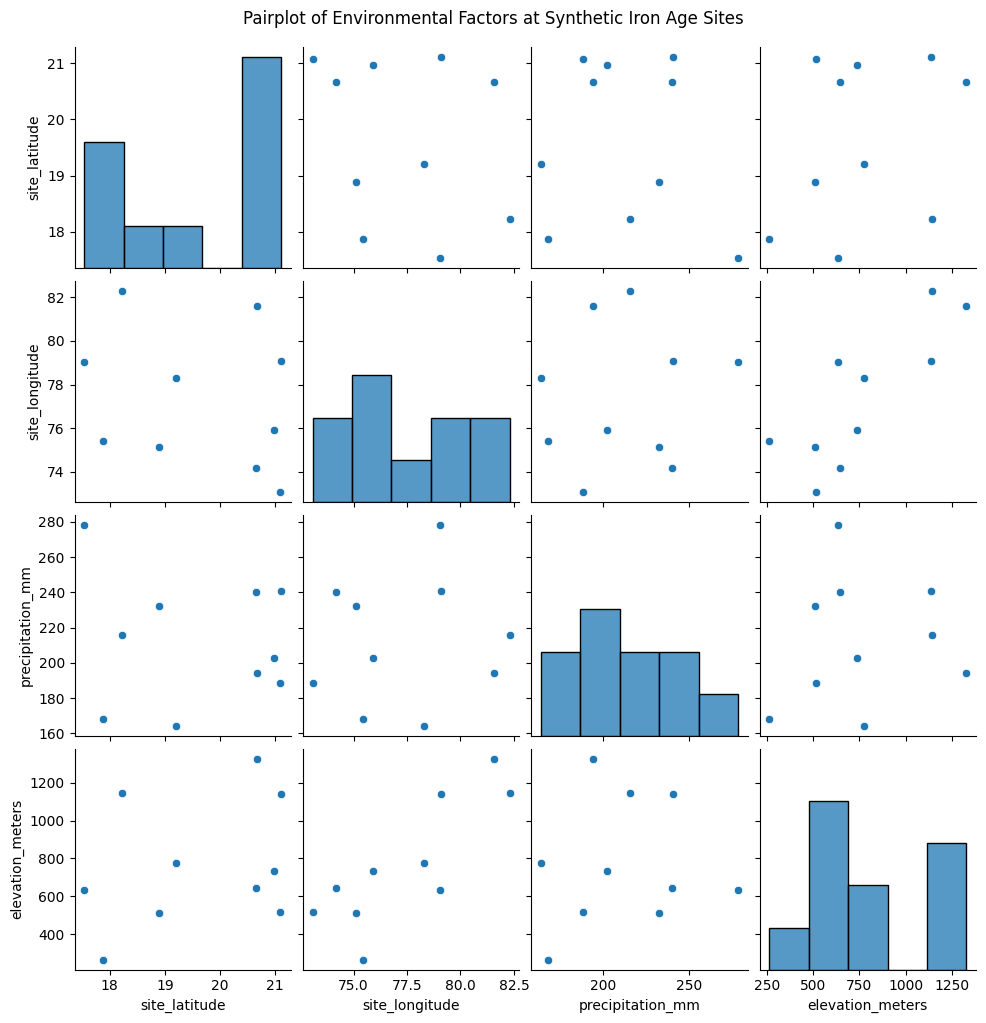

In [16]:
import seaborn as sns
import matplotlib.pyplot as plt

# Create a pairplot of all variables in synthetic_sites_df
# This will generate scatter plots for each pair of variables and histograms for individual variables
fig = sns.pairplot(synthetic_sites_df)
plt.suptitle('Pairplot of Environmental Factors at Synthetic Iron Age Sites', y=1.02) # Adjust suptitle position
plt.show()

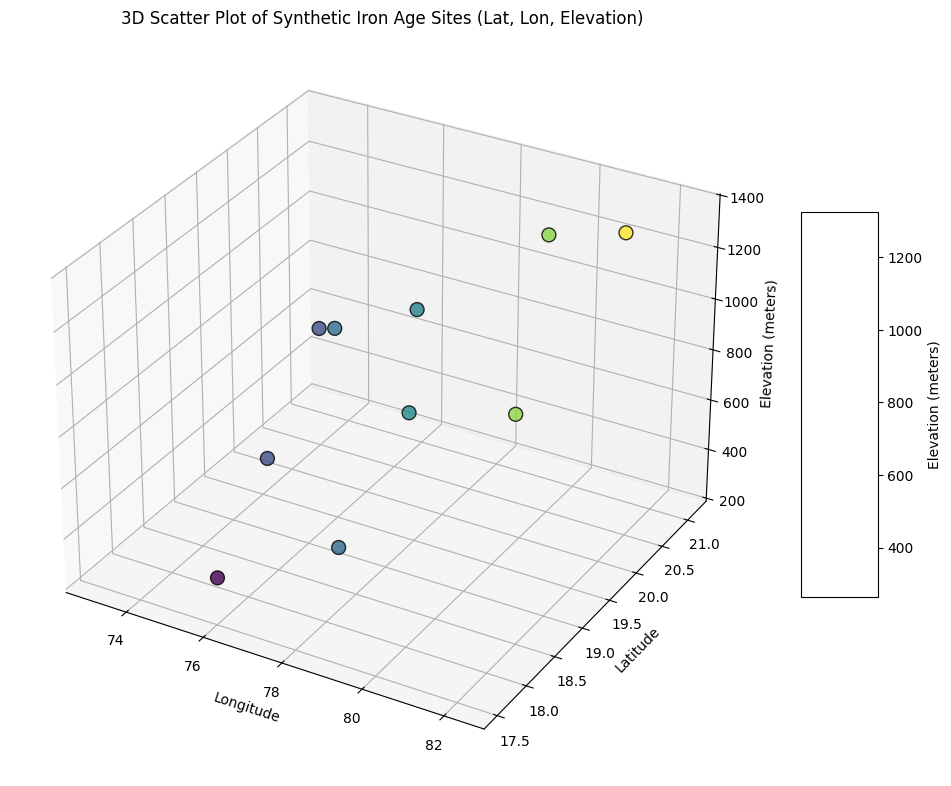

In [17]:
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# Create a 3D scatter plot
fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Scatter plot
ax.scatter(
    synthetic_sites_df['site_longitude'],
    synthetic_sites_df['site_latitude'],
    synthetic_sites_df['elevation_meters'],
    c=synthetic_sites_df['elevation_meters'], # Color points by elevation
    cmap='viridis', # Colormap for elevation
    s=100, # Size of markers
    edgecolor='black', # Edge color for markers
    alpha=0.8
)

# Set labels and title
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_zlabel('Elevation (meters)')
ax.set_title('3D Scatter Plot of Synthetic Iron Age Sites (Lat, Lon, Elevation)')

# Add a color bar for elevation
cbar = fig.colorbar(ax.scatter(
    synthetic_sites_df['site_longitude'],
    synthetic_sites_df['site_latitude'],
    synthetic_sites_df['elevation_meters'],
    c=synthetic_sites_df['elevation_meters'],
    cmap='viridis',
    s=0, # Make points invisible for colorbar purpose
    alpha=0
), shrink=0.5, aspect=5)
cbar.set_label('Elevation (meters)')

plt.show()

In [18]:
# Calculate the median elevation to use as a threshold for classification
median_elevation = synthetic_sites_df['elevation_meters'].median()

# Create the new 'elevation_category' column
synthetic_sites_df['elevation_category'] = synthetic_sites_df['elevation_meters'].apply(
    lambda x: 'high' if x > median_elevation else 'low'
)

print(f"Median Elevation used for classification: {median_elevation:.2f} meters")
print("Updated synthetic_sites_df with 'elevation_category' column:")
display(synthetic_sites_df)

Median Elevation used for classification: 689.74 meters
Updated synthetic_sites_df with 'elevation_category' column:


,site_latitude,site_longitude,precipitation_mm,elevation_meters,elevation_category
0,19.201812,78.305228,164.349024,773.927007,high
1,18.219708,82.296494,215.688628,1144.373957,high
2,20.659601,74.168613,240.159628,644.661545,low
3,17.868821,75.421352,168.240982,264.864749,low
4,20.670201,81.587108,194.149696,1326.796150,high
5,18.893731,75.117571,232.443384,511.141280,low
6,20.974926,75.901673,202.435838,734.811108,high
7,17.538963,79.044752,278.302487,632.751826,low
8,21.081602,73.086651,188.338953,517.341505,low
9,21.109855,79.101940,240.954841,1138.992237,high


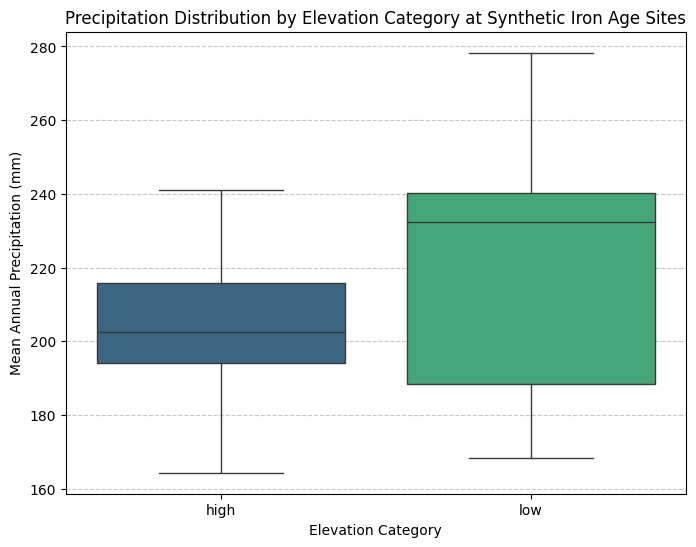

In [19]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.boxplot(x='elevation_category', y='precipitation_mm', data=synthetic_sites_df, palette='viridis')
plt.title('Precipitation Distribution by Elevation Category at Synthetic Iron Age Sites')
plt.xlabel('Elevation Category')
plt.ylabel('Mean Annual Precipitation (mm)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

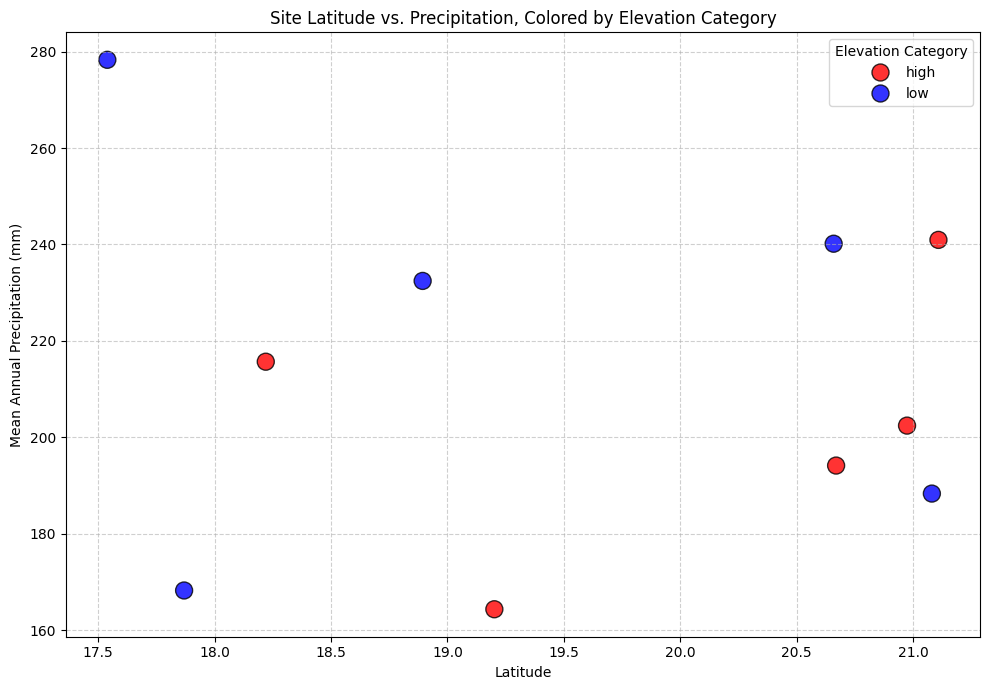

In [20]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 7))
sns.scatterplot(
    x='site_latitude',
    y='precipitation_mm',
    hue='elevation_category',
    data=synthetic_sites_df,
    s=150, # Size of the markers
    alpha=0.8,
    edgecolor='black',
    palette={'high': 'red', 'low': 'blue'} # Custom colors for clarity
)
plt.title('Site Latitude vs. Precipitation, Colored by Elevation Category')
plt.xlabel('Latitude')
plt.ylabel('Mean Annual Precipitation (mm)')
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend(title='Elevation Category')
plt.tight_layout()
plt.show()

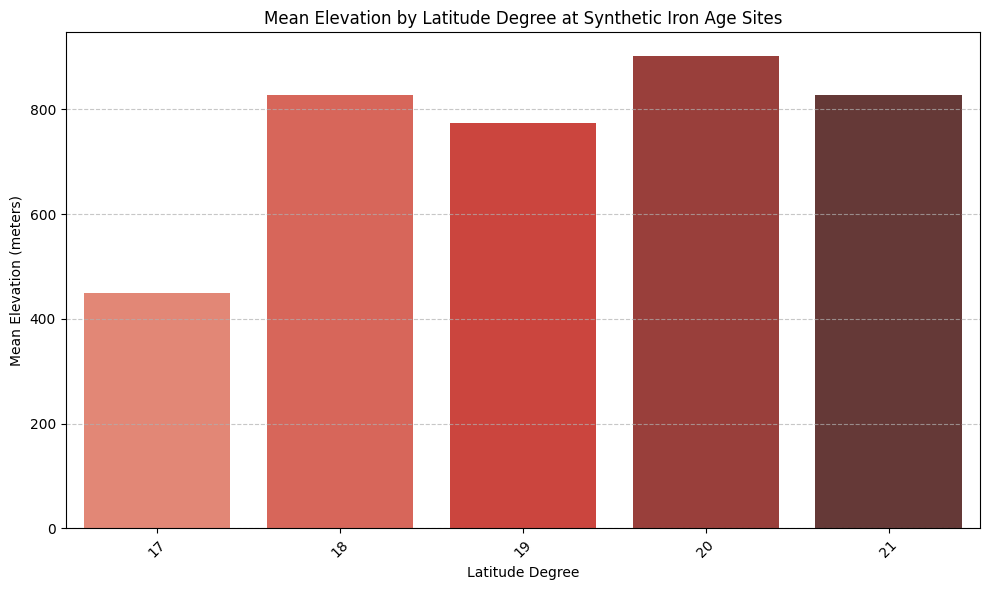

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# Extract the integer part of the latitude to group by latitude degree
synthetic_sites_df['latitude_degree'] = synthetic_sites_df['site_latitude'].astype(int)

# Calculate the mean elevation for each latitude degree
mean_elevation_by_latitude = synthetic_sites_df.groupby('latitude_degree')['elevation_meters'].mean().reset_index()

plt.figure(figsize=(10, 6))
sns.barplot(
    x='latitude_degree',
    y='elevation_meters',
    data=mean_elevation_by_latitude,
    palette='Reds_d' # A divergent color palette
)
plt.title('Mean Elevation by Latitude Degree at Synthetic Iron Age Sites')
plt.xlabel('Latitude Degree')
plt.ylabel('Mean Elevation (meters)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45) # Rotate x-axis labels if they overlap
plt.tight_layout()
plt.show()

In [22]:
import pandas as pd

# Calculate summary statistics for 'precipitation_mm' grouped by 'elevation_category'
precipitation_summary_stats = synthetic_sites_df.groupby('elevation_category')['precipitation_mm'].describe()

print("Summary Statistics for Precipitation grouped by Elevation Category:")
display(precipitation_summary_stats)

Summary Statistics for Precipitation grouped by Elevation Category:


,count,mean,std,min,25%,50%,75%,max
elevation_category,,,,,,,,
high,5.0,203.515605,28.163745,164.349024,194.149696,202.435838,215.688628,240.954841
low,5.0,221.497087,43.676767,168.240982,188.338953,232.443384,240.159628,278.302487
